In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for "Executive" look
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the processed data
# We use '..' to go up one level from 'notebooks/' then into 'data/'
df = pd.read_csv('../data/processed/cleaned_sales_data.csv')

# Parse date (csv saves it as string)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print("Data Loaded Successfully.")
print(f"Time Range: {df.index.min()} to {df.index.max()}")
df.head()

Data Loaded Successfully.
Time Range: 2023-01-01 00:00:00 to 2024-12-30 02:50:00


,price,discount,promotion_intensity,footfall,ad_spend,competitor_price,stock_level,weather_index,customer_sentiment,return_rate
date,,,,,,,,,,
2023-01-01 00:00:00,45.197454,5.514259,4.062653,277.017484,2559.073870,44.255411,1176.981397,7.442194,1.021762,0.067388
2023-01-01 01:10:00,49.327512,6.572035,4.964657,250.760714,2536.417155,50.331704,1219.359497,6.759510,0.975142,0.082719
2023-01-01 02:20:00,47.328457,6.972713,4.363191,263.130478,2552.952356,49.285996,1263.822738,5.941689,0.871567,0.061600
2023-01-01 03:30:00,50.964538,4.808234,3.577988,297.603918,2605.398826,46.839936,1182.435378,8.517014,1.071300,0.052215
2023-01-01 04:40:00,44.530213,8.180216,4.966638,208.931691,2432.485683,45.336500,1178.513263,8.422473,1.068515,0.057975


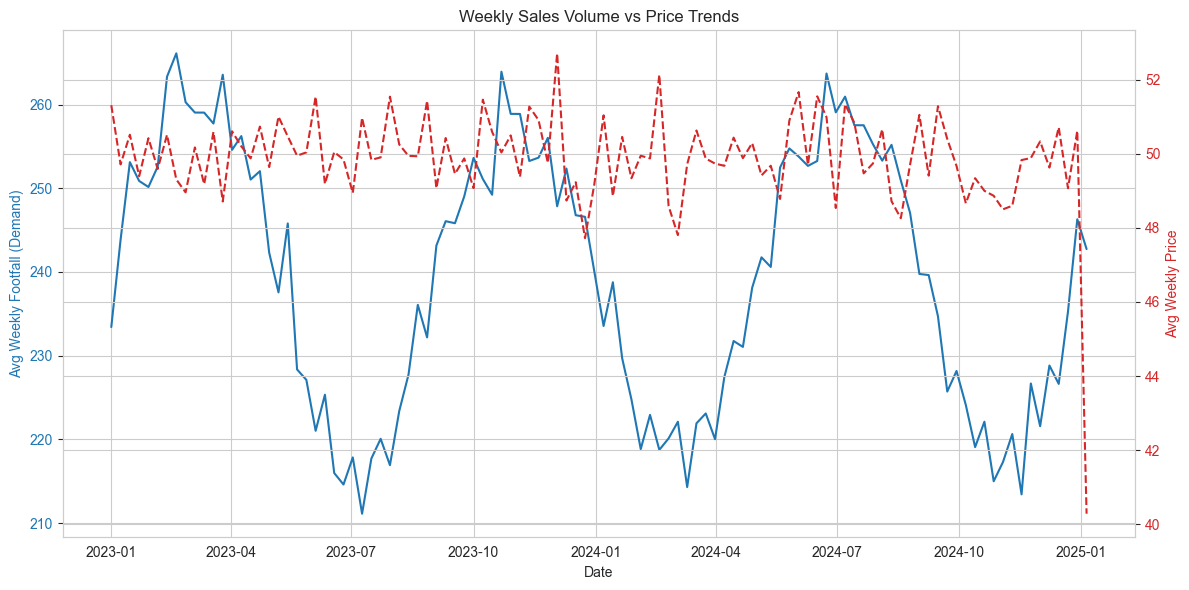

In [2]:
# Resample to Weekly to reduce noise and see the trend clearly
weekly_sales = df['footfall'].resample('W').mean() # using footfall as proxy for demand
weekly_price = df['price'].resample('W').mean()

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Avg Weekly Footfall (Demand)', color=color)
ax1.plot(weekly_sales.index, weekly_sales, color=color, label='Footfall')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Avg Weekly Price', color=color)  # we already handled the x-label with ax1
ax2.plot(weekly_price.index, weekly_price, color=color, linestyle='--', label='Price')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Weekly Sales Volume vs Price Trends')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

# Interpretation: 
# If Price (Red) goes UP and Footfall (Blue) goes DOWN, we have elastic demand.

In [3]:
# 1. Competitor Price Gap (Absolute difference)
df['competitor_diff'] = df['price'] - df['competitor_price']

# 2. Price Ratio (Relative difference - often better for modeling)
df['price_ratio'] = df['price'] / df['competitor_price']

# 3. Revenue (Target Variable for Optimization)
# Note: We are estimating Sales Volume = Footfall * Conversion Rate (assumed const or modeled later)
# For this EDA, let's treat 'footfall' as our demand proxy or derive a 'sales_volume' 
# assuming a conversion rate of 10% just to visualize Revenue.
df['estimated_sales'] = (df['footfall'] * 0.10).round().astype(int)
df['revenue'] = df['price'] * df['estimated_sales']

# 4. Log Transformation for Elasticity (Log-Log Model requirement)
# Adding +1 to avoid log(0) errors if any, though we cleaned zeros already.
df['log_price'] = np.log(df['price'] + 1)
df['log_demand'] = np.log(df['estimated_sales'] + 1)

# 5. Interaction Term: Price * Promotion Intensity
# Captures if promotions make people less sensitive to high prices
df['price_x_promo'] = df['price'] * df['promotion_intensity']

# 6. Rolling Averages (To capture history)
df['rolling_price_7d'] = df['price'].rolling(window=7).mean()

# Drop the NaNs created by rolling
df.dropna(inplace=True)

print("Feature Engineering Complete. New Columns Added:")
print(df[['competitor_diff', 'price_ratio', 'revenue', 'log_price', 'price_x_promo']].head())

Feature Engineering Complete. New Columns Added:
                     competitor_diff  price_ratio      revenue  log_price  \
date                                                                        
2023-01-01 07:00:00         3.244497     1.071324  1364.551876   3.906689   
2023-01-01 08:10:00         2.676138     1.087456   898.449507   3.534443   
2023-01-01 09:20:00        -1.164121     0.975705  1215.538979   3.866010   
2023-01-01 10:30:00         4.428945     1.136457   811.484955   3.634573   
2023-01-01 11:40:00         2.002330     1.040142  1141.445208   3.968098   

                     price_x_promo  
date                                
2023-01-01 07:00:00     186.332124  
2023-01-01 08:10:00     149.776962  
2023-01-01 09:20:00     252.237346  
2023-01-01 10:30:00     220.865497  
2023-01-01 11:40:00     199.074865  


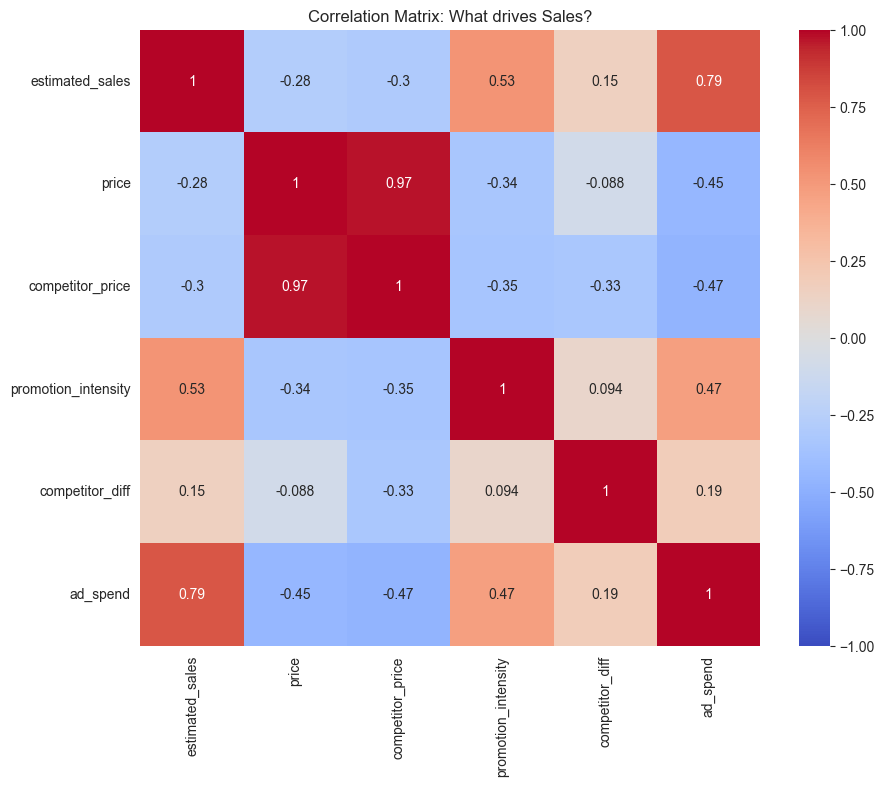

Engineered data saved to data/processed/featured_sales_data.csv


In [4]:
# Select only numeric columns for correlation
cols_to_check = ['estimated_sales', 'price', 'competitor_price', 
                 'promotion_intensity', 'competitor_diff', 'ad_spend']

corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: What drives Sales?')
plt.show()

# Save the engineered data for Step 3 (Modeling)
# We overwrite or save as new? Let's save as new to be safe.
df.to_csv('../data/processed/featured_sales_data.csv')
print("Engineered data saved to data/processed/featured_sales_data.csv")

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Conclusion: Data is Stationary (Good for modeling)")
    else:
        print("Conclusion: Data is Non-Stationary (Needs differencing)")

print("--- Checking Stationarity for Footfall (Demand) ---")
adf_test(df['footfall'])

--- Checking Stationarity for Footfall (Demand) ---
ADF Statistic: -7.210982548226862
p-value: 2.2352563754678576e-10
Conclusion: Data is Stationary (Good for modeling)
